# Twierdzenie Stonea-Weierstrassa — weryfikacja eksperymentalna

**Twierdzenie Stonea-Weierstrassa:** Dla każdej funkcji ciągłej
$f \in C[a, b]$ oraz każdego $\varepsilon > 0$ istnieje wielomian
$P_n$ taki, że:

$$\|f - P_n\|_\infty < \varepsilon$$

Oznacza to, że każdy ciągłą funkcję na przedziale $[a, b]$ można
dowolnie dokładnie przybliżyć wielomianem, pod warunkiem że stopień
jest wystarczająco wysoki.

W ćwiczeniu sprawdzamy eksperymentalnie: jaki minimalny stopień
wielomianu jest potrzebny, aby osiągnąć $R^2 > 0.99$ dla czterech
funkcji testowych.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 10        # mniej węzłów (bliższe interpolacji)
a, b = 1, 20
xx = np.linspace(a, b, N)

y1 = xx**6 * np.exp(-xx)
y2 = np.sin(xx) * np.exp(-xx)
y3 = np.abs(xx)
wsp_fun4 = np.array([3, 2, 1, 0, 1, 7, 5, 2])
y4 = np.polyval(wsp_fun4, xx)

print(f"Liczba węzłów: {N}, przedział [{a}, {b}]")

Liczba węzłów: 10, przedział [1, 20]


In [2]:
results = []
for name, yy in [('f1: x^6·exp(-x)', y1),
                  ('f2: sin(x)·exp(-x)', y2),
                  ('f3: |x|', y3),
                  ('f4: wielomian stopnia 7', y4)]:
    threshold_deg = None
    print(f"Funkcja: {name}")
    for deg in range(1, N):
        wsp = np.polyfit(xx, yy, deg)
        yy_fit = np.polyval(wsp, xx)
        ss_res = np.sum((yy - yy_fit)**2)
        ss_tot = np.sum((yy - np.mean(yy))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        print(f"  deg={deg}, R²={r2:.8f}")
        # zapamiętujemy PIERWSZY stopień powyżej progu, ale pętli NIE przerywamy --
        # dla fun4 musimy dojść do deg=7, żeby faktycznie zweryfikować dopasowanie idealne
        if threshold_deg is None and r2 > 0.99:
            threshold_deg = deg
    if threshold_deg is not None:
        print(f"  -> Minimalny stopień z R²>0.99: {threshold_deg}")
        results.append((name, threshold_deg))
    else:
        print("  Nie osiągnięto R² > 0.99")
    print()

Funkcja: f1: x^6·exp(-x)
  deg=1, R²=0.24262758
  deg=2, R²=0.45487684
  deg=3, R²=0.87687618
  deg=4, R²=0.90048117
  deg=5, R²=0.94984780
  deg=6, R²=0.99489727
  deg=7, R²=0.99994952
  deg=8, R²=0.99995022
  deg=9, R²=1.00000000
  -> Minimalny stopień z R²>0.99: 6

Funkcja: f2: sin(x)·exp(-x)
  deg=1, R²=0.26970271
  deg=2, R²=0.57392228
  deg=3, R²=0.80635790
  deg=4, R²=0.93428789
  deg=5, R²=0.98449618
  deg=6, R²=0.99776740
  deg=7, R²=0.99985266
  deg=8, R²=0.99999843
  deg=9, R²=1.00000000
  -> Minimalny stopień z R²>0.99: 6

Funkcja: f3: |x|
  deg=1, R²=1.00000000
  deg=2, R²=1.00000000
  deg=3, R²=1.00000000
  deg=4, R²=1.00000000
  deg=5, R²=1.00000000
  deg=6, R²=1.00000000
  deg=7, R²=1.00000000
  deg=8, R²=1.00000000
  deg=9, R²=1.00000000
  -> Minimalny stopień z R²>0.99: 1

Funkcja: f4: wielomian stopnia 7
  deg=1, R²=0.57475732
  deg=2, R²=0.90265396
  deg=3, R²=0.98898725
  deg=4, R²=0.99947049
  deg=5, R²=0.99999182
  deg=6, R²=0.99999998
  deg=7, R²=1.00000000
  de

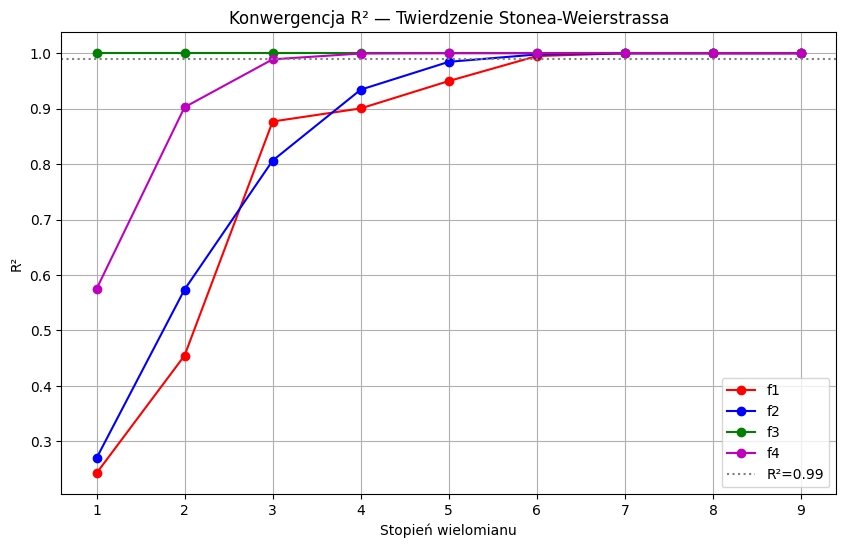

In [3]:
all_funcs = [y1, y2, y3, y4]
colors = ['r', 'b', 'g', 'm']
labels = ['f1', 'f2', 'f3', 'f4']

plt.figure(figsize=(10, 6))
for func, color, label in zip(all_funcs, colors, labels):
    r2_values = []
    for deg in range(1, N):
        wsp = np.polyfit(xx, func, deg)
        func_fit = np.polyval(wsp, xx)
        ss_res = np.sum((func - func_fit)**2)
        ss_tot = np.sum((func - np.mean(func))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        r2_values.append(r2)
    plt.plot(range(1, N), r2_values, 'o-', color=color, label=label)

plt.axhline(0.99, color='grey', linestyle=':', label='R²=0.99')
plt.xlabel('Stopień wielomianu')
plt.ylabel('R²')
plt.title('Konwergencja R² — Twierdzenie Stonea-Weierstrassa')
plt.legend()
plt.grid(True)
plt.show()

## Wnioski

1. **Im wyższy stopień**, tym lepsze dopasowanie — potwierdza twierdzenie
   Stonea-Weierstrassa.

2. **Granica aproksymacji a interpolacji:** Gdy stopień
   $M = N-1 = 9$, mamy $M+1 = N = 10$ współczynników do
   dopasowania na $N = 10$ punktach — to jest interpolacja
   (dokładne przejście przez wszystkie punkty).

3. **Zjawisko Runge'a:** Przy bardzo wysokich stopniach i
   jednorodnie rozmieszczonych węzłach mogą pojawić się oscylacje
   na krańcach przedziału.

4. **Wielomian fun4** ($\deg = 7$) jest idealnie dopasowywany
   przy stopniu $\geq 7$, ponieważ aproksymujemy wielomian
   wielomianem.

## Ćwiczenie 1

Zmień przedział $[a, b]$ (np. $[1, 10]$, $[0, 50]$, $[10, 30]$)
i sprawdź:
- Czy optymalny stopień zależy od przedziału?
- Co się dzieje przy bardzo dużym przedziale?
- Zwróć uwagę na przejście między aproksymacją a interpolacją,
  gdy $M$ zbliża się do $N-1$.

### Szybkodostęp
| Skróty | Działanie |
|---|---|
| `Ctrl+Enter` | Uruchom komórkę |
| `Shift+Enter` | Uruchom i przejdź dalej |
| `Shift+Tab` | Tooltip |
| `Alt+Enter` | Uruchom i wstaw nową |